<center><p float="center">
  <img src="https://upload.wikimedia.org/wikipedia/commons/e/e9/4_RGB_McCombs_School_Brand_Branded.png" width="300" height="100"/>
  <img src="https://mma.prnewswire.com/media/1458111/Great_Learning_Logo.jpg?p=facebook" width="200" height="100"/>
</p></center>

<center><font size=10>Artificial Intelligence and Machine Learning</font></center>
<center><font size=6>Ensemble Techniques and Model Tuning</font></center>

<center><img src="https://images.pexels.com/photos/7235894/pexels-photo-7235894.jpeg?auto=compress&cs=tinysrgb&w=1260&h=750&dpr=2" width="800" height="500"></center>

<center><font size=6>Visa Approval Facilitation</font></center>

# **Problem Statement**

## Context

Business communities in the United States are facing high demand for human resources, but one of the constant challenges is identifying and attracting the right talent, which is perhaps the most important element in remaining competitive. Companies in the United States look for hard-working, talented, and qualified individuals both locally as well as abroad.

The Immigration and Nationality Act (INA) of the US permits foreign workers to come to the United States to work on either a temporary or permanent basis. The act also protects US workers against adverse impacts on their wages or working conditions by ensuring US employers' compliance with statutory requirements when they hire foreign workers to fill workforce shortages. The immigration programs are administered by the Office of Foreign Labor Certification (OFLC).

OFLC processes job certification applications for employers seeking to bring foreign workers into the United States and grants certifications in those cases where employers can demonstrate that there are not sufficient US workers available to perform the work at wages that meet or exceed the wage paid for the occupation in the area of intended employment.

## Objective

In FY 2016, the OFLC processed 775,979 employer applications for 1,699,957 positions for temporary and permanent labor certifications. This was a nine percent increase in the overall number of processed applications from the previous year. The process of reviewing every case is becoming a tedious task as the number of applicants is increasing every year.

The increasing number of applicants every year calls for a Machine Learning based solution that can help in shortlisting the candidates having higher chances of VISA approval. OFLC has hired the firm EasyVisa for data-driven solutions. You as a data  scientist at EasyVisa have to analyze the data provided and, with the help of a classification model:

* Facilitate the process of visa approvals.
* Recommend a suitable profile for the applicants for whom the visa should be certified or denied based on the drivers that significantly influence the case status.

## Data Description

The data contains the different attributes of employee and the employer. The detailed data dictionary is given below.

* case_id: ID of each visa application
* continent: Information of continent the employee
* education_of_employee: Information of education of the employee
* has_job_experience: Does the employee has any job experience? Y= Yes; N = No
* requires_job_training: Does the employee require any job training? Y = Yes; N = No
* no_of_employees: Number of employees in the employer's company
* yr_of_estab: Year in which the employer's company was established
* region_of_employment: Information of foreign worker's intended region of employment in the US.
* prevailing_wage:  Average wage paid to similarly employed workers in a specific occupation in the area of intended employment. The purpose of the prevailing wage is to ensure that the foreign worker is not underpaid compared to other workers offering the same or similar service in the same area of employment.
* unit_of_wage: Unit of prevailing wage. Values include Hourly, Weekly, Monthly, and Yearly.
* full_time_position: Is the position of work full-time? Y = Full Time Position; N = Part Time Position
* case_status:  Flag indicating if the Visa was certified or denied

## Note: This is a sample solution for the project. Projects will NOT be graded on the basis of how well the submission matches this sample solution. Projects will be graded on the basis of the rubric only.

# **Importing necessary libraries**

In [1]:
# Installing the libraries with the specified version.
# !pip install numpy==2.0.2 pandas==2.2.2 scikit-learn==1.6.1 matplotlib==3.10.0 seaborn==0.13.2 xgboost==3.0.5 -q --user

**Note**: *After running the above cell, kindly restart the notebook kernel and run all cells sequentially from the start again.*

In [2]:
import warnings

warnings.filterwarnings("ignore")

# Libraries to help with reading and manipulating data
import numpy as np
import pandas as pd

# Library to split data
from sklearn.model_selection import train_test_split

# libaries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Removes the limit for the number of displayed columns
pd.set_option("display.max_columns", None)
# Sets the limit for the number of displayed rows
pd.set_option("display.max_rows", 100)

# To oversample and undersample data
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

# Libraries different ensemble classifiers
from sklearn.ensemble import (
    BaggingClassifier,
    RandomForestClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier,
    StackingClassifier,
)

from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier

# Libraries to get different metric scores
from sklearn import metrics
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)

# To tune different models
from sklearn.model_selection import GridSearchCV
# To Encode data in XGBClassifier
from sklearn.preprocessing import LabelEncoder

# **Loading the dataset**

In [3]:
df = pd.read_csv("EasyVisa.csv")
data = df.copy()


# **Overview of the Dataset**

* Observations

* Sanity checks

In [4]:
data.head()

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified


In [5]:
data.tail()

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
25475,EZYV25476,Asia,Bachelor's,Y,Y,2601,2008,South,77092.57,Year,Y,Certified
25476,EZYV25477,Asia,High School,Y,N,3274,2006,Northeast,279174.79,Year,Y,Certified
25477,EZYV25478,Asia,Master's,Y,N,1121,1910,South,146298.85,Year,N,Certified
25478,EZYV25479,Asia,Master's,Y,Y,1918,1887,West,86154.77,Year,Y,Certified
25479,EZYV25480,Asia,Bachelor's,Y,N,3195,1960,Midwest,70876.91,Year,Y,Certified


In [6]:
data.shape

(25480, 12)

In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25480 entries, 0 to 25479
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   case_id                25480 non-null  object 
 1   continent              25480 non-null  object 
 2   education_of_employee  25480 non-null  object 
 3   has_job_experience     25480 non-null  object 
 4   requires_job_training  25480 non-null  object 
 5   no_of_employees        25480 non-null  int64  
 6   yr_of_estab            25480 non-null  int64  
 7   region_of_employment   25480 non-null  object 
 8   prevailing_wage        25480 non-null  float64
 9   unit_of_wage           25480 non-null  object 
 10  full_time_position     25480 non-null  object 
 11  case_status            25480 non-null  object 
dtypes: float64(1), int64(2), object(9)
memory usage: 2.3+ MB


In [8]:
# checking missing values in the data
data.isna().sum()

case_id                  0
continent                0
education_of_employee    0
has_job_experience       0
requires_job_training    0
no_of_employees          0
yr_of_estab              0
region_of_employment     0
prevailing_wage          0
unit_of_wage             0
full_time_position       0
case_status              0
dtype: int64

In [9]:
# Check for duplicates
data.duplicated().sum()

np.int64(0)

* There are no duplicate values in the data

# <a name='link2'>**Exploratory Data Analysis (EDA)**</a>

- EDA is an important part of any project involving data.
- It is important to investigate and understand the data better before building a model with it.
- A few questions have been mentioned below which will help you approach the analysis in the right manner and generate insights from the data.
- A thorough analysis of the data, in addition to the questions mentioned below, should be done.

**Leading Questions**

What is the distribution of visa case statuses (certified vs. denied)?


1. What is the distribution of visa case statuses (certified vs. denied)?
2. How does the education level of employees impact visa approval rates?
3. Is there a significant difference in visa approval rates between employees with and without prior job experience?
4. How does the prevailing wage affect visa approval? Do higher wages lead to higher chances of approval?
5. Do certain regions in the US have higher visa approval rates compared to others?
6. How does the number of employees in a company influence visa approval? Do larger companies have a higher approval rate?
7. Are visa approval rates different across various continents of employees? Which continent has the highest and lowest approval rates?

In [10]:
# Number of unique values in each column
data.nunique()

case_id                  25480
continent                    6
education_of_employee        4
has_job_experience           2
requires_job_training        2
no_of_employees           7105
yr_of_estab                199
region_of_employment         5
prevailing_wage          25454
unit_of_wage                 4
full_time_position           2
case_status                  2
dtype: int64

In [11]:
cat_cols=['continent','education_of_employee','has_job_experience','requires_job_training','region_of_employment',
          'unit_of_wage','full_time_position','case_status']

cols = data.select_dtypes(['object']).columns.tolist()

print('cat_cols:', cat_cols)
print('cols:', cols)

# for column in cat_cols:
#     print(data[column].value_counts())
#     print('-'*30)

cat_cols: ['continent', 'education_of_employee', 'has_job_experience', 'requires_job_training', 'region_of_employment', 'unit_of_wage', 'full_time_position', 'case_status']
cols: ['case_id', 'continent', 'education_of_employee', 'has_job_experience', 'requires_job_training', 'region_of_employment', 'unit_of_wage', 'full_time_position', 'case_status']


In [12]:
# Summary of continuous columns
data[['no_of_employees','yr_of_estab','prevailing_wage']].describe().T

,count,mean,std,min,25%,50%,75%,max
no_of_employees,25480.0,5667.043210,22877.928848,-26.0000,1022.00,2109.00,3504.0000,602069.00
yr_of_estab,25480.0,1979.409929,42.366929,1800.0000,1976.00,1997.00,2005.0000,2016.00
prevailing_wage,25480.0,74455.814592,52815.942327,2.1367,34015.48,70308.21,107735.5125,319210.27


### Functions to display plots

In [13]:
def histogram_boxplot(data, feature, figsize=(15, 10), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (15,10))
    kde: whether to show the density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a triangle will indicate the mean value of the column
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )  # Add median to the histogram


# function to create labeled barplots
def labeled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 2, 6))
    else:
        plt.figure(figsize=(n + 2, 6))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n],
        hue='case_status'
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    plt.show()  # show the plot

# function to plot stacked bar chart


def stacked_barplot(data, predictor, target):
    """
    Print the category counts and plot a stacked bar chart

    data: dataframe
    predictor: independent variable
    target: target variable
    """
    count = data[predictor].nunique()
    sorter = data[target].value_counts().index[-1]
    tab1 = pd.crosstab(data[predictor], data[target], margins=True).sort_values(
        by=sorter, ascending=False
    )
    print(tab1)
    print("-" * 120)
    tab = pd.crosstab(data[predictor], data[target], normalize="index").sort_values(
        by=sorter, ascending=False
    )
    tab.plot(kind="bar", stacked=True, figsize=(count + 1, 5))
    plt.legend(
        loc="lower left",
        frameon=False,
    )
    plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
    plt.show()



### Univariate Analysis

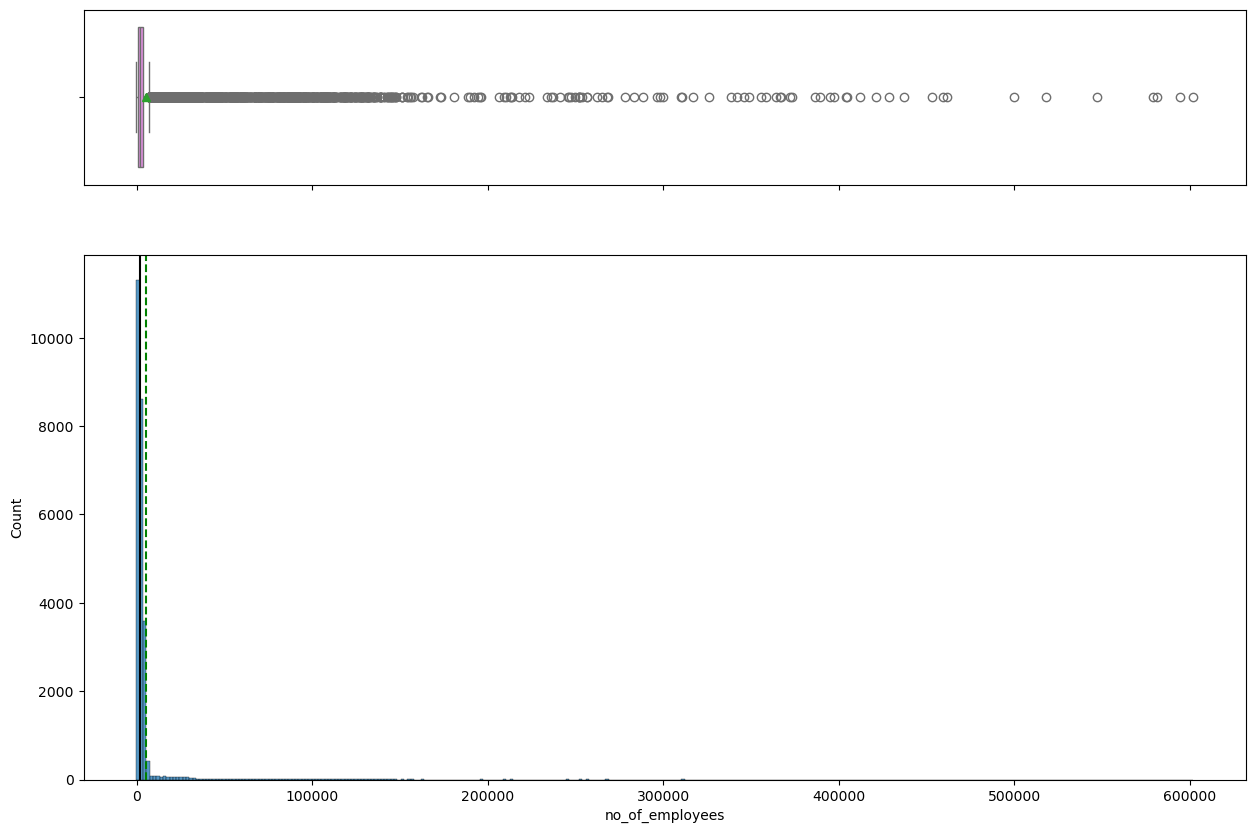

In [14]:
histogram_boxplot(data,'no_of_employees')

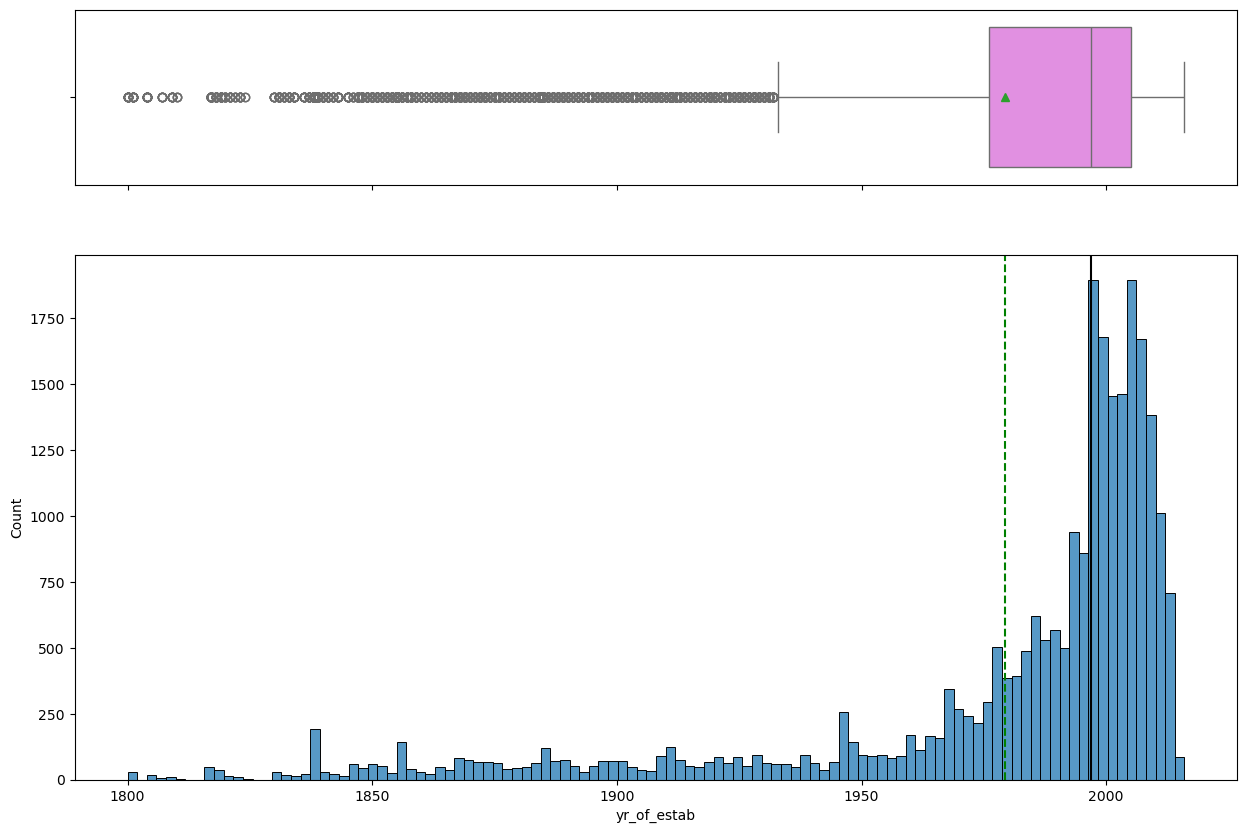

In [15]:
histogram_boxplot(data,'yr_of_estab')

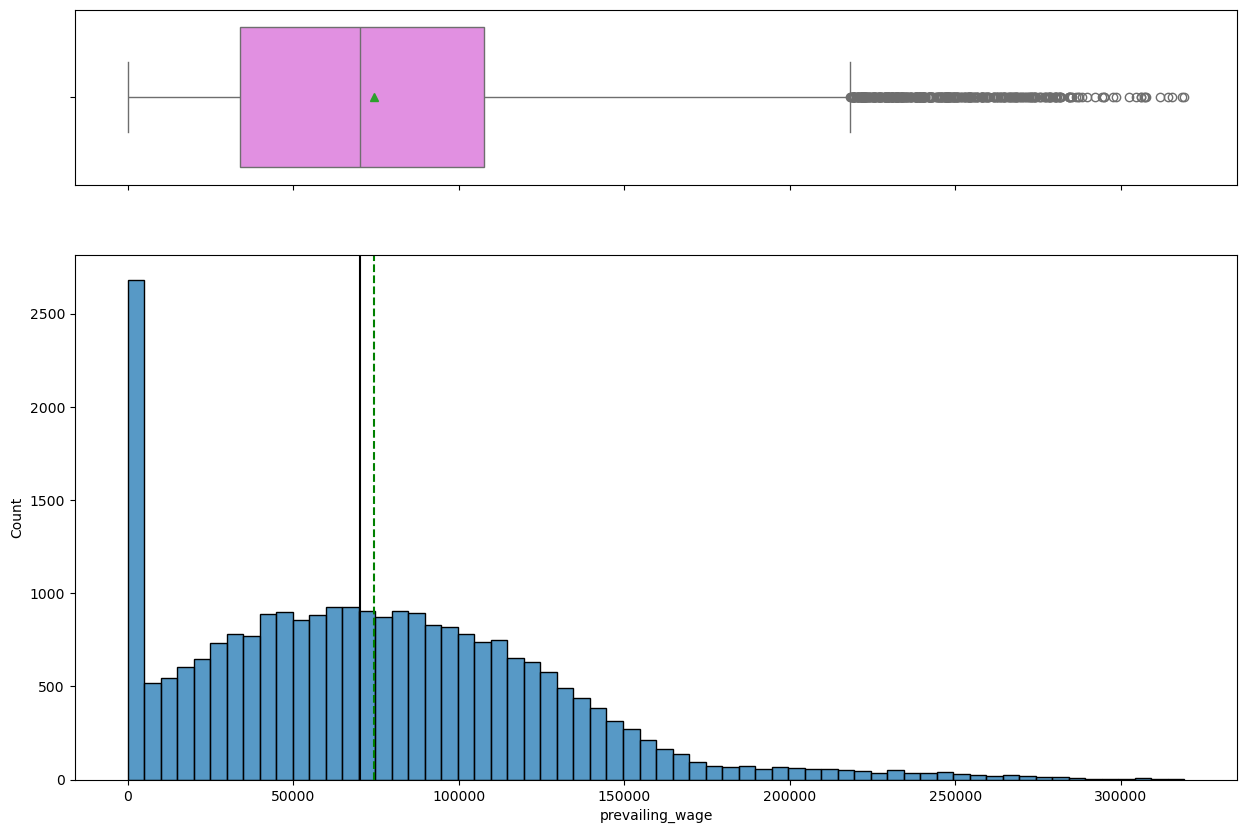

In [16]:
histogram_boxplot(data,'prevailing_wage')

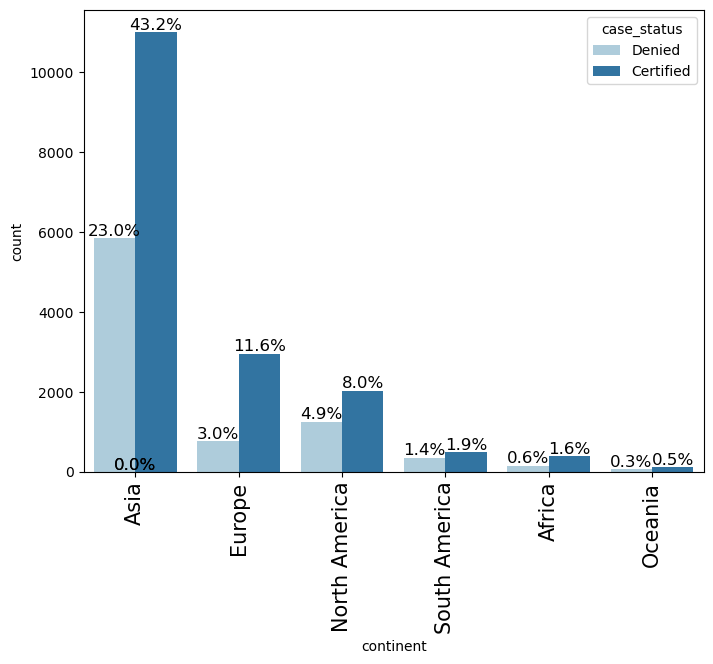

------------------------------


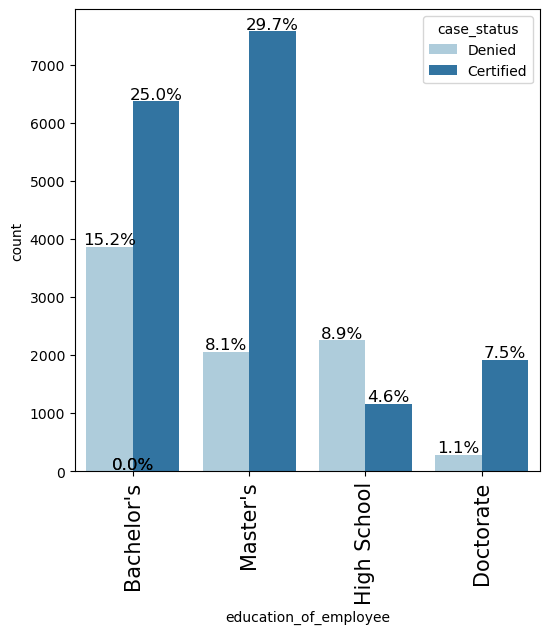

------------------------------


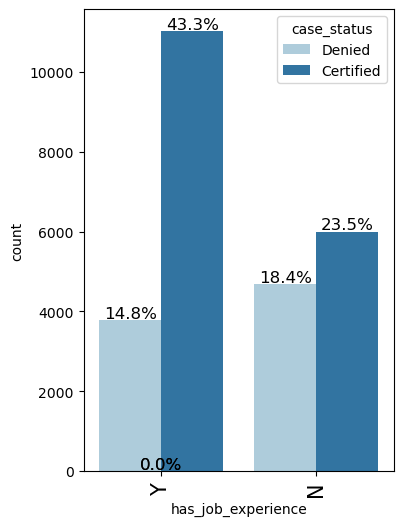

------------------------------


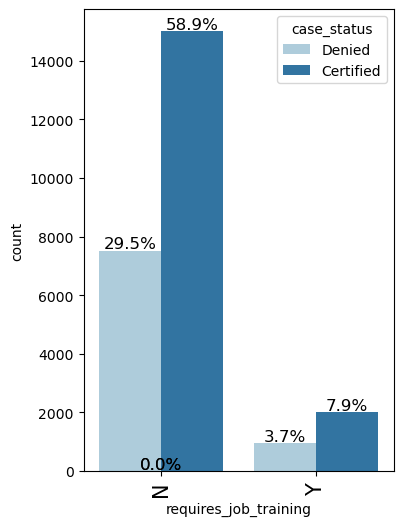

------------------------------


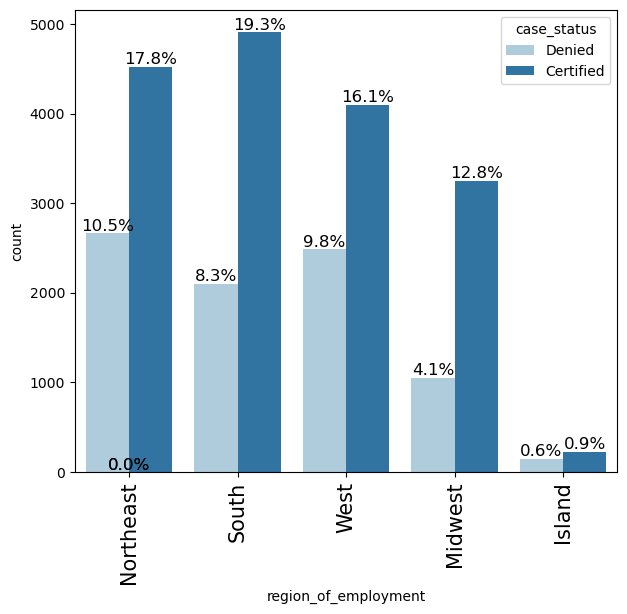

------------------------------


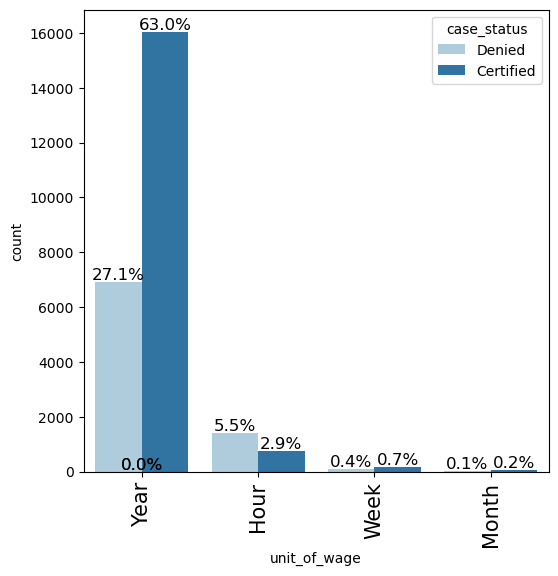

------------------------------


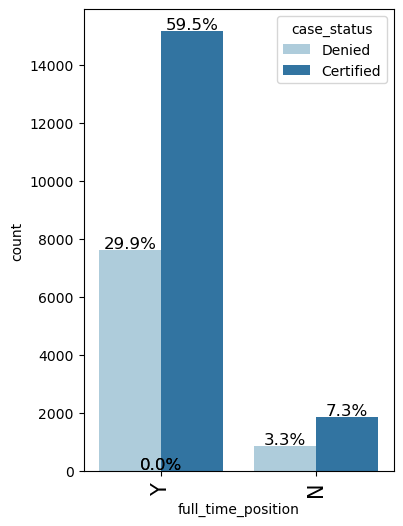

------------------------------


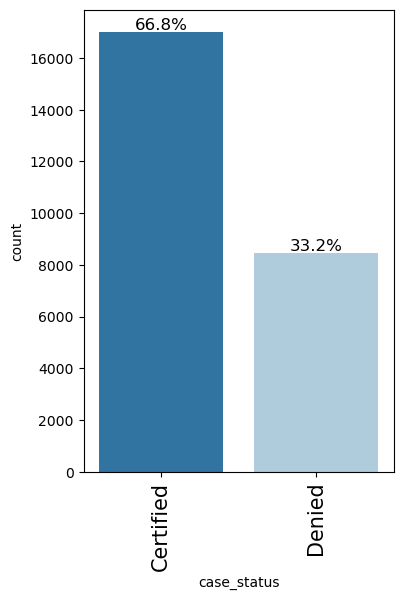

------------------------------


In [17]:
# 
for column in cat_cols:
    labeled_barplot(data, column, perc=True)
    print('-'*30)

### Bivariate Analysis

#### Correlation check

* Not much correlation between continuous variables

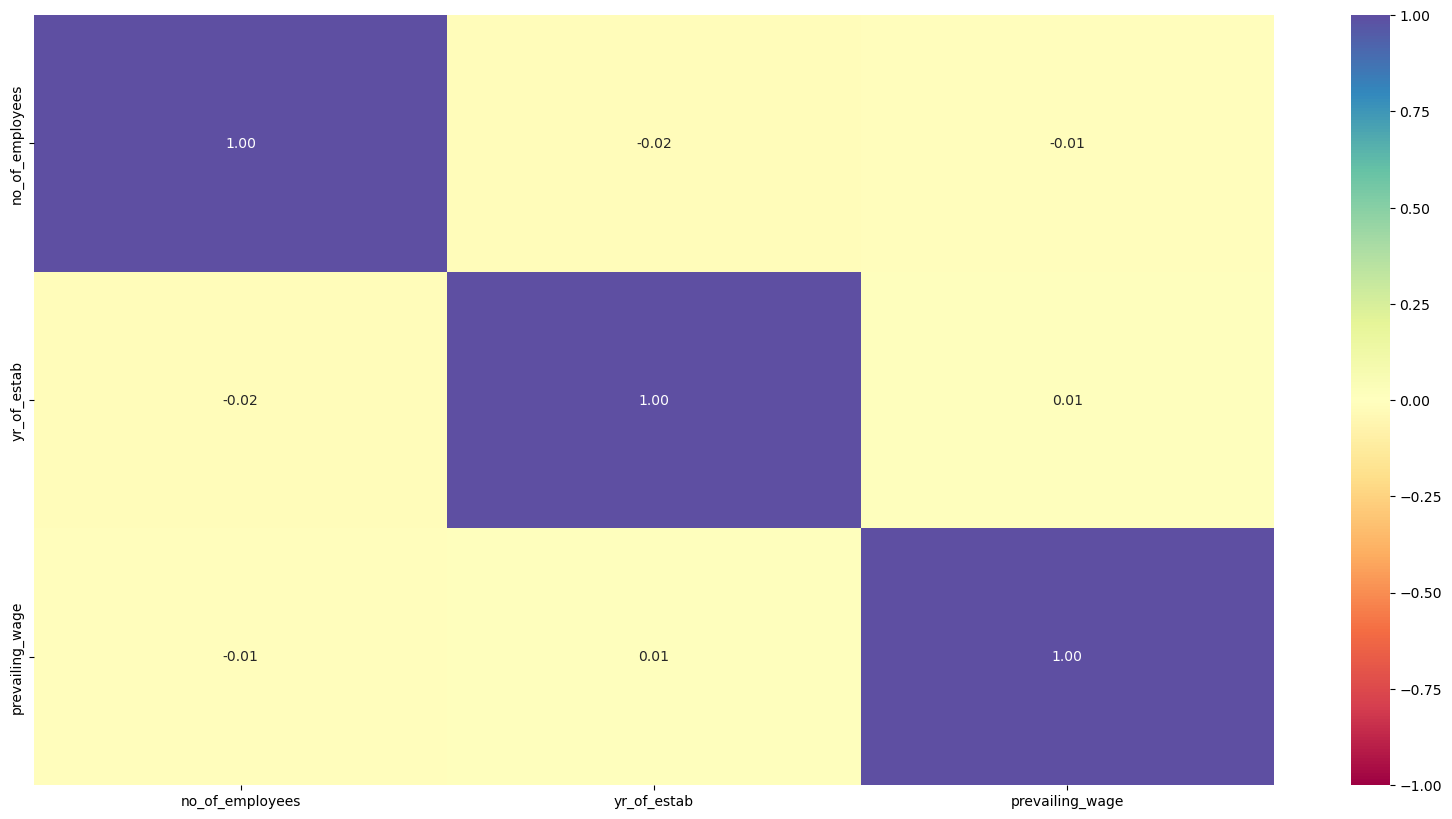

In [18]:
plt.figure(figsize=(20,10))
sns.heatmap(data.corr(numeric_only=True),annot=True,vmin=-1,vmax=1,fmt='.2f',cmap="Spectral")
plt.show()

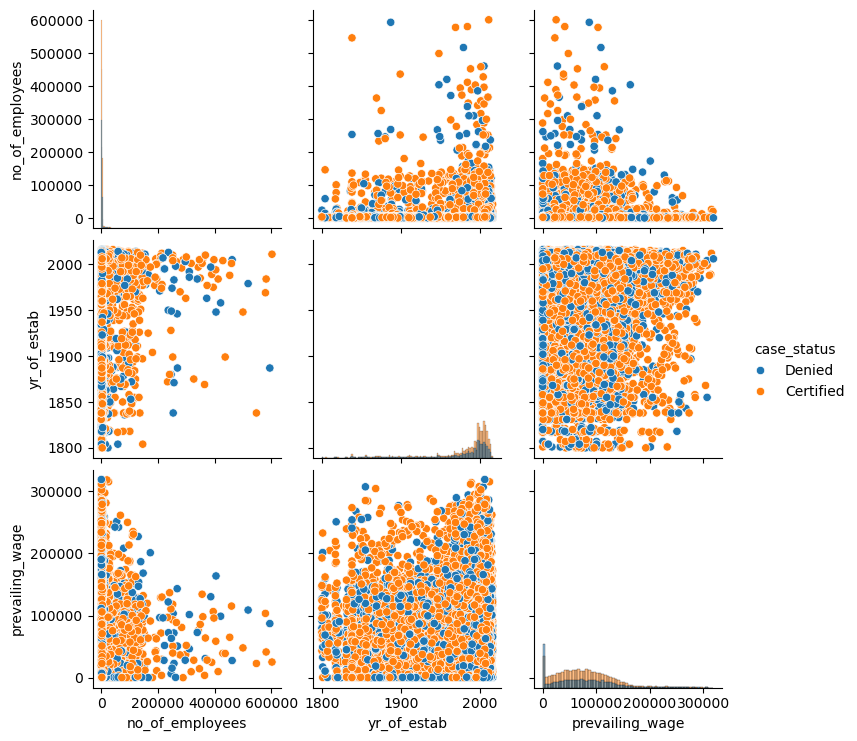

In [19]:
sns.pairplot(data, hue = 'case_status' , diag_kind='hist')

# **Data Pre-processing**

- Missing value treatment (if needed)
- Feature engineering (if needed)
- Outlier detection and treatment (if needed)
- Preparing data for modeling
- Any other preprocessing steps (if needed)

In [20]:
#Dropping the ID column from the dataframe because it provides no value for analysis
data.drop(columns=['case_id'], inplace=True)

In [21]:
data['case_status'].value_counts()

case_status
Certified    17018
Denied        8462
Name: count, dtype: int64

In [22]:
# Make "case_status" equal to 1 or 0 instead of "certified" or "Denied"
data["case_status"].replace("Certified", 1, inplace=True)
data["case_status"].replace("Denied", 0, inplace=True)

data['case_status'].value_counts()



case_status
1    17018
0     8462
Name: count, dtype: int64

In [23]:
cols = data.select_dtypes(['object'])
cols.columns

Index(['continent', 'education_of_employee', 'has_job_experience',
       'requires_job_training', 'region_of_employment', 'unit_of_wage',
       'full_time_position'],
      dtype='object')

In [24]:
for i in cols.columns:
    data[i] = data[i].astype('category')

In [25]:
data.dtypes

continent                category
education_of_employee    category
has_job_experience       category
requires_job_training    category
no_of_employees             int64
yr_of_estab                 int64
region_of_employment     category
prevailing_wage           float64
unit_of_wage             category
full_time_position       category
case_status                 int64
dtype: object

In [26]:
# separating the independent and dependent variables
X = data.drop(["case_status"], axis=1)
y = data["case_status"]

X.shape
y.head()

0    0
1    1
2    0
3    0
4    1
Name: case_status, dtype: int64

In [27]:
# creating dummy variables
# converts category type variable into one hot encoded variables
# order doesn't matter when using one hot encoded variables
# drop_first=True is used to prevent multicollinearity in the OHC variables.  Multi-collinearity is when
# two features are closely correlated and can affect the stability and interpretation of regression models.
X = pd.get_dummies(X, drop_first=True)

X.shape

(25480, 21)

In [28]:
# Splitting data into training, validation and test set:

# first we split data into 2 parts, say temporary and test
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.5, random_state=0, stratify=y
)

# then we split the temporary set into train and validation
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.4, random_state=0, stratify=y_temp
)

print(X_train.shape, X_val.shape, X_test.shape)

(12740, 21) (7644, 21) (5096, 21)


In [29]:
# Checking class balance for whole data, train set, validation set, and test set

print("Target value ratio in y")
print(y.value_counts(1))
print("*" * 80)
print("Target value ratio in y_train")
print(y_train.value_counts(1))
print("*" * 80)
print("Target value ratio in y_val")
print(y_val.value_counts(1))
print("*" * 80)
print("Target value ratio in y_test")
print(y_test.value_counts(1))
print("*" * 80)

Target value ratio in y
case_status
1    0.667896
0    0.332104
Name: proportion, dtype: float64
********************************************************************************
Target value ratio in y_train
case_status
1    0.667896
0    0.332104
Name: proportion, dtype: float64
********************************************************************************
Target value ratio in y_val
case_status
1    0.667844
0    0.332156
Name: proportion, dtype: float64
********************************************************************************
Target value ratio in y_test
case_status
1    0.667975
0    0.332025
Name: proportion, dtype: float64
********************************************************************************


# **Model Building**

Model Building - Original Data
- Build atleast 5 classification models (Using decision trees, random forest, bagging classifier and boosting methods)

* You can choose not to build XGBoost if you are facing issues with installation
Points:6

In [47]:
modelAcc = {}

In [48]:
# Bagging Classifier
name = "BaggingClassifier"
#base_estimator for bagging classifier is a decision tree by default
bagging_estimator=BaggingClassifier(random_state=1)
bagging_estimator.fit(X_train,y_train)

scores = accuracy_score(y_train, bagging_estimator.predict(X_train))  # to compute Accuracy
modelAcc[name] = scores
print("{}: {}".format(name, scores))


BaggingClassifier: 0.9842229199372057


In [49]:
#Random forest classifier
name = "RandomForestClassifier"
rf_estimator=RandomForestClassifier(random_state=1)
rf_estimator.fit(X_train,y_train)

scores = accuracy_score(y_train, rf_estimator.predict(X_train))  # to compute Accuracy
modelAcc[name] = scores
print("{}: {}".format(name, scores))

RandomForestClassifier: 1.0


In [51]:
# AdaBoostClassifier
name = "AdaBoostClassifier"
abc = AdaBoostClassifier(random_state=1)
abc.fit(X_train,y_train)

scores = accuracy_score(y_train, abc.predict(X_train))  # to compute Accuracy
modelAcc[name] = scores
print("{}: {}".format(name, scores))

AdaBoostClassifier: 0.7387755102040816


In [50]:
# GradientBoostingClassifier
name = "GradientBoostingClassifier"
gbc = GradientBoostingClassifier(random_state=1)
gbc.fit(X_train,y_train)

scores = accuracy_score(y_train, gbc.predict(X_train))  # to compute Accuracy
modelAcc[name] = scores
print("{}: {}".format(name, scores))

GradientBoostingClassifier: 0.7571428571428571


In [52]:
# XGBClassifier
name = "XGBClassifier"
xgb = XGBClassifier(random_state=1,eval_metric='logloss')
xgb.fit(X_train, y_train)

scores = accuracy_score(y_train, xgb.predict(X_train))  # to compute Accuracy
modelAcc[name] = "XGBClassifier"
print("{}: {}".format(name, scores))


XGBClassifier: 0.859497645211931


In [53]:
modelAcc

{'BaggingClassifier': 0.9842229199372057,
 'RandomForestClassifier': 1.0,
 'GradientBoostingClassifier': 0.7571428571428571,
 'AdaBoostClassifier': 0.7387755102040816,
 'XGBClassifier': 'XGBClassifier'}


Model Building - Oversampled Data
- Build atleast 5 classification models using oversampled train data (Using decision trees, random forest, bagging classifier and boosting methods)

* You can choose not to build XGBoost if you are facing issues with the installation
Points
6

In [54]:
print("Before Oversampling, counts of label 'Certified': {}".format(sum(y_train == 1)))
print("Before Oversampling, counts of label 'Denied': {} \n".format(sum(y_train == 0)))

sm = SMOTE(
    sampling_strategy=1, k_neighbors=5, random_state=1
)  # Synthetic Minority Over Sampling TEchnique
X_train_over, y_train_over = sm.fit_resample(X_train, y_train)


print("After Oversampling, counts of label 'Certified': {}".format(sum(y_train_over == 1)))
print("After Oversampling, counts of label 'Denied': {} \n".format(sum(y_train_over == 0)))


print("After Oversampling, the shape of train_X: {}".format(X_train_over.shape))
print("After Oversampling, the shape of train_y: {} \n".format(y_train_over.shape))

Before Oversampling, counts of label 'Certified': 8509
Before Oversampling, counts of label 'Denied': 4231 

After Oversampling, counts of label 'Certified': 8509
After Oversampling, counts of label 'Denied': 8509 

After Oversampling, the shape of train_X: (17018, 21)
After Oversampling, the shape of train_y: (17018,) 



##### Create a List of models that can be fitted with oversampled training data

In [57]:
models_under = []  # List of models

# Appending models into the list
models_under.append(("Bagging_over", BaggingClassifier(estimator=DecisionTreeClassifier(random_state=1, class_weight='balanced'), random_state=1)))
models_under.append(("Random forest_over", RandomForestClassifier(random_state=1, class_weight='balanced')))
models_under.append(("GBM_over", GradientBoostingClassifier(random_state=1)))
models_under.append(("Adaboost_over", AdaBoostClassifier(random_state=1)))
models_under.append(("dtree_over", DecisionTreeClassifier(random_state=1, class_weight='balanced')))

for name, model in models_under:
    model.fit(X_train_over, y_train_over)
    scores = accuracy_score(y_train_over, model.predict(X_train_over))  # to compute Accuracy
    modelAcc[name] = scores
    print("{}: {}".format(name, scores))

Bagging_over: 0.9866611822775885
Random forest_over: 1.0
GBM_over: 0.7956869197320484
Adaboost_over: 0.7713597367493242
dtree_over: 1.0


Model Building - Undersampled Data
- Build atleast 5 classification models using undersampled train data (Using decision trees, random forest, bagging classifier and boosting methods)

* You can choose not to build XGBoost if you are facing issues with the installation
Points
6

In [58]:
print("Before Undersampling, counts of label 'Certified': {}".format(sum(y_train == 1)))
print("Before Undersampling, counts of label 'Denied': {} \n".format(sum(y_train == 0)))

rus = RandomUnderSampler(random_state=1)
X_train_under, y_train_under = rus.fit_resample(X_train, y_train)

print("After Undersampling, counts of label 'Certified': {}".format(sum(y_train_under == 1)))
print("After Undersampling, counts of label 'Denied': {} \n".format(sum(y_train_under == 0)))

print("After Undersampling, the shape of train_X_under: {}".format(X_train_under.shape))
print("After Undersampling, the shape of train_y_under: {} \n".format(y_train_under.shape))

Before Undersampling, counts of label 'Certified': 8509
Before Undersampling, counts of label 'Denied': 4231 

After Undersampling, counts of label 'Certified': 4231
After Undersampling, counts of label 'Denied': 4231 

After Undersampling, the shape of train_X_under: (8462, 21)
After Undersampling, the shape of train_y_under: (8462,) 



In [59]:
models_under = []  # List of models

# Appending models into the list
models_under.append(("Bagging_under", BaggingClassifier(estimator=DecisionTreeClassifier(random_state=1, class_weight='balanced'), random_state=1)))
models_under.append(("Random forest_under", RandomForestClassifier(random_state=1, class_weight='balanced')))
models_under.append(("GBM_under", GradientBoostingClassifier(random_state=1)))
models_under.append(("Adaboost_under", AdaBoostClassifier(random_state=1)))
models_under.append(("dtree_under", DecisionTreeClassifier(random_state=1, class_weight='balanced')))

for name, model in models_under:
    model.fit(X_train_under, y_train_under)
    scores = accuracy_score(y_train_under, model.predict(X_train_under))  # to compute Accuracy
    modelAcc[name] = scores
    #calculate and print accuracy score
    print("{}: {}".format(name, scores))


Bagging_under: 0.9800283620893406
Random forest_under: 1.0
GBM_under: 0.7231151028125739
Adaboost_under: 0.691562278421177
dtree_under: 1.0


In [60]:
modelAcc

{'BaggingClassifier': 0.9842229199372057,
 'RandomForestClassifier': 1.0,
 'GradientBoostingClassifier': 0.7571428571428571,
 'AdaBoostClassifier': 0.7387755102040816,
 'XGBClassifier': 'XGBClassifier',
 'Bagging_under': 0.9800283620893406,
 'Random forest_under': 1.0,
 'GBM_under': 0.7231151028125739,
 'Adaboost_under': 0.691562278421177,
 'dtree_under': 1.0,
 'Bagging_over': 0.9866611822775885,
 'Random forest_over': 1.0,
 'GBM_over': 0.7956869197320484,
 'Adaboost_over': 0.7713597367493242,
 'dtree_over': 1.0}

## Model evaluation criterion


**What does EasyVisa want?**
* It wants to streamline the process of granting applications using a computer instead of people.

**Which loss is greater ?**
**Since we want to reduce loan defaults we should use Recall as a metric of model evaluation instead of accuracy.**
* Recall - It gives the ratio of True positives to Actual positives, so high Recall implies low false negatives, i.e. low chances of predicting a bad customer as a good customer.


# **Model Performance Improvement**

## **Note**

1. Sample parameter grids have been provided to do necessary hyperparameter tuning. These sample grids are expected to provide a balance between model performance improvement and execution time. One can extend/reduce the parameter grid based on execution time and system configuration.
  - Please note that if the parameter grid is extended to improve the model performance further, the execution time will increase
2. The models chosen in this notebook are based on test runs. One can update the best models as obtained upon code execution and tune them for best performance.

- For Gradient Boosting:

```
param_grid = {
    "init": [AdaBoostClassifier(random_state=1),DecisionTreeClassifier(random_state=1)],
    "n_estimators": np.arange(50,110,25),
    "learning_rate": [0.01,0.1,0.05],
    "subsample":[0.7,0.9],
    "max_features":[0.5,0.7,1],
}
```

- For Adaboost:

```
param_grid = {
    "n_estimators": np.arange(50,110,25),
    "learning_rate": [0.01,0.1,0.05],
    "base_estimator": [
        DecisionTreeClassifier(max_depth=2, random_state=1),
        DecisionTreeClassifier(max_depth=3, random_state=1),
    ],
}
```

- For Bagging Classifier:

```
param_grid = {
    'max_samples': [0.8,0.9,1],
    'max_features': [0.7,0.8,0.9],
    'n_estimators' : [30,50,70],
}
```
- For Random Forest:

```
param_grid = {
    "n_estimators": [50,110,25],
    "min_samples_leaf": np.arange(1, 4),
    "max_features": [np.arange(0.3, 0.6, 0.1),'sqrt'],
    "max_samples": np.arange(0.4, 0.7, 0.1)
}
```

- For Decision Trees:

```
param_grid = {
    'max_depth': np.arange(2,6),
    'min_samples_leaf': [1, 4, 7],
    'max_leaf_nodes' : [10, 15],
    'min_impurity_decrease': [0.0001,0.001]
}
```

- For XGBoost:

```
param_grid={'n_estimators':np.arange(50,110,25),
            'scale_pos_weight':[1,2,5],
            'learning_rate':[0.01,0.1,0.05],
            'gamma':[1,3],
            'subsample':[0.7,0.9]
}
```


# **Model Comparison and Final Model Selection**

# **Actionable Insights and Recommendations**



*   



___